<a href="https://colab.research.google.com/github/gatilhoroxo/comp-math-comp/blob/main/parte-1/bisection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bisection Method – Numerical Root Finding

This notebook implements the **bisection method** to compute a root of the function:

$$ f(x) = x^3 + x - 1 $$

The notebook also produces a **table of iterations** showing the interval updates and midpoint at each step.

This notebook is compatible with **Google Colab**.

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bisection(f, a, b, tol=1e-6, max_iter=100):
    """
    Bisection method for root finding.

    Returns:
        root: approximated root
        table: pandas DataFrame with iteration details
    """

    fa = f(a);
    fb = f(b);
    if fa * fb >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    rows = []

    for i in range(1, max_iter + 1):

        c = (a + b) / 2;
        fc = f(c);

        rows.append({
            "iteration": i,
            "a": a,
            "b": b,
            "midpoint": c,
            "f(midpoint)": fc,
            "interval_width": b - a
        })

        if fc == 0 or (b - a)/2 < tol:
            break

        if fa * fc < 0:
            b = c;
            fb = fc;
        else:
            a = c;
            fa = fc;

    table = pd.DataFrame(rows)
    return c, table


In [154]:
# Define the function
def f(x):
    return x**5 + x - 1

funcao = "x**5 + x - 1"

In [155]:
# Definindo um grafico para ver a função
def grafico(a, b):
    x_val = np.linspace(a,b, 400)
    y_val = f(x_val)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_val, y_val, label=rf'{funcao}')

    # Linha horizontal do eixo X
    plt.axhline(0, color='black', linewidth=1) 
    # Linha vertical do eixo Y
    plt.axvline(0, color='black', linewidth=1) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.title('Gráfico da Função')
    plt.xlabel('Eixo X')
    plt.ylabel('Eixo Y')
    plt.legend()

    plt.show()

In [156]:
# "main"

# Initial interval
a = -2
b = 1


# Run the bisection method
root, table = bisection(f, a, b, 1e-8)

print("Approximate root:", root)
print("f(root) =", f(root))

# Display iteration table
table


Approximate root: 0.7548776622861624
f(root) = -1.0390806992610635e-08


,iteration,a,b,midpoint,f(midpoint),interval_width
0,1,-2.000000,1.000000,-0.500000,-1.531250e+00,3.000000e+00
1,2,-0.500000,1.000000,0.250000,-7.490234e-01,1.500000e+00
2,3,0.250000,1.000000,0.625000,-2.796326e-01,7.500000e-01
3,4,0.625000,1.000000,0.812500,1.665926e-01,3.750000e-01
4,5,0.625000,0.812500,0.718750,-8.943203e-02,1.875000e-01
5,6,0.718750,0.812500,0.765625,2.870058e-02,9.375000e-02
6,7,0.718750,0.765625,0.742188,-3.261261e-02,4.687500e-02
7,8,0.742188,0.765625,0.753906,-2.544544e-03,2.343750e-02
8,9,0.753906,0.765625,0.759766,1.292744e-02,1.171875e-02
9,10,0.753906,0.759766,0.756836,5.154239e-03,5.859375e-03


## Gráfico da Função escolhida

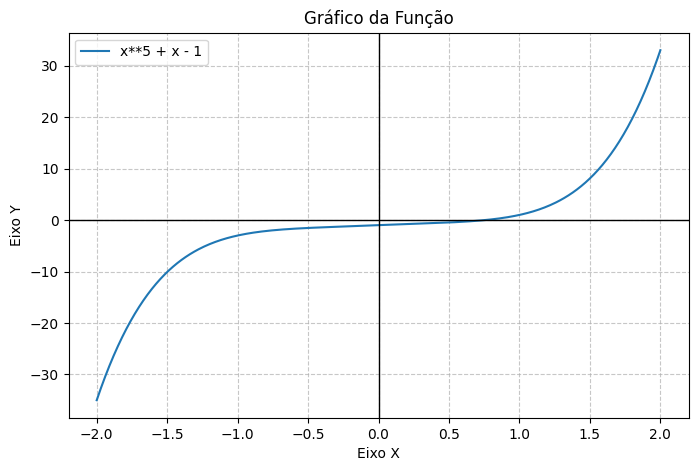

In [157]:


xa = -2
xb = 2

grafico(xa,xb)